# Part 1: Feasibility & Quality — Statistical Analysis

Implements the complete plan from `analysis.md`.

In [16]:
import pandas as pd
import numpy as np
import re, os, warnings
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multitest import multipletests
from itertools import combinations, product
from scipy import stats as scipy_stats

warnings.filterwarnings('ignore', category=UserWarning)

DATA_DIR = 'data'
DIMENSIONS = ['Accuracy', 'Lay_Relevancy', 'Helpfulness']
ALPHA = 0.05

## 1. Data Loading & Preparation

In [17]:
# Load narratives (Strategy from filename)
strategy_files = {
    'zero_shot.csv':'zero_shot','few_shot.csv':'few_shot',
    'cot_zero_shot.csv':'cot_zero_shot','cot_few_shot.csv':'cot_few_shot',
    'self_consistency.csv':'self_consistency','reflexion.csv':'reflexion',
    'role_based.csv':'role_based','meta_prompting.csv':'meta_prompting'
}
dfs = []
for f, s in strategy_files.items():
    d = pd.read_csv(os.path.join(DATA_DIR, f)); d['Strategy'] = s; dfs.append(d)
narratives = pd.concat(dfs, ignore_index=True)

# Load G-Eval scores
geval_gpt = pd.read_csv(os.path.join(DATA_DIR, 'geval_gpt4.csv'))
geval_ds  = pd.read_csv(os.path.join(DATA_DIR, 'geval_deepseek.csv'))

ID_COLS = ['LLM','Model','XAI','WeekEndDate','Strategy']
SCORE_GPT = {'eval_accuracy_g_eval_score':'Accuracy','eval_lay_user_relevancy_g_eval_score':'Lay_Relevancy','eval_usefulness_explanation_helpfulness_g_eval_score':'Helpfulness'}
SCORE_DS = {'eval_accuracy_traditional_score':'Accuracy','eval_lay_user_relevancy_traditional_score':'Lay_Relevancy','eval_usefulness_explanation_helpfulness_traditional_score':'Helpfulness'}

gpt_sc = geval_gpt[ID_COLS + list(SCORE_GPT.keys())].rename(columns=SCORE_GPT)
ds_sc  = geval_ds[ID_COLS + list(SCORE_DS.keys())].rename(columns=SCORE_DS)

# Average across judges (section 6.2)
merged = gpt_sc.merge(ds_sc, on=ID_COLS, suffixes=('_gpt','_ds'))
for dim in DIMENSIONS:
    merged[dim] = (merged[f'{dim}_gpt'] + merged[f'{dim}_ds']) / 2

df = merged[ID_COLS + DIMENSIONS + [f'{d}_gpt' for d in DIMENSIONS] + [f'{d}_ds' for d in DIMENSIONS]].copy()
df['Instance'] = df['WeekEndDate']
df = df.merge(narratives[ID_COLS + ['Explanation']], on=ID_COLS, how='left')

# RQ subsets (section 6.4)
df_full = df.copy()
df_no_sarimax = df[df['Model'] != 'SARIMAX'].copy()
df_xai_none = df[df['XAI'] == 'none'].copy()

print(f'N={len(df)}, no_sarimax={len(df_no_sarimax)}, xai_none={len(df_xai_none)}')
print(df[DIMENSIONS].describe().round(3).to_string())
print('\nCeiling (% at 5.0):')
for d in DIMENSIONS: print(f'  {d}: {(df[d]==5.0).mean()*100:.1f}%')
print('\n', pd.crosstab(df['Model'], df['XAI']))
print('\n', pd.crosstab(df['LLM'], df['Strategy']))

N=660, no_sarimax=594, xai_none=264
       Accuracy  Lay_Relevancy  Helpfulness
count   660.000        660.000      660.000
mean      4.525          4.287        4.310
std       0.580          0.549        0.502
min       1.984          2.996        2.494
25%       4.389          4.000        4.001
50%       4.500          4.449        4.418
75%       5.000          4.504        4.496
max       5.000          5.000        5.000

Ceiling (% at 5.0):
  Accuracy: 0.5%
  Lay_Relevancy: 0.0%
  Helpfulness: 0.0%

 XAI           lime  none  shap
Model                         
MLP             66    66    66
RandomForest    66    66    66
SARIMAX          0    66     0
XGB             66    66    66

 Strategy  cot_few_shot  cot_zero_shot  few_shot  meta_prompting  reflexion  \
LLM                                                                          
DEEPSEEK             0              0        30              30         30   
GPT                 30             30        30              30 

---
## Part A: Structural Compliance (section 4)

=== Word Count (<=200) ===
Compliant: 470/660 (71.2%), Mean=183.9, SD=44.8, Min=76, Max=381
Violations (190):
  LLM: {'L3_LOCAL': np.int64(131), 'GPT': np.int64(56), 'DEEPSEEK': np.int64(3)}
  Model: {'XGB': np.int64(61), 'MLP': np.int64(58), 'RandomForest': np.int64(53), 'SARIMAX': np.int64(18)}
  XAI: {'lime': np.int64(65), 'none': np.int64(65), 'shap': np.int64(60)}
  Strategy: {'cot_zero_shot': np.int64(37), 'reflexion': np.int64(35), 'meta_prompting': np.int64(31), 'role_based': np.int64(30), 'zero_shot': np.int64(28), 'self_consistency': np.int64(24), 'cot_few_shot': np.int64(3), 'few_shot': np.int64(2)}

=== Bullet Points (<=6) ===
Compliant: 596/660 (90.3%), Mean=5.4, SD=2.0, Min=0, Max=13
Violations (64):
  LLM: {'DEEPSEEK': np.int64(32), 'L3_LOCAL': np.int64(30), 'GPT': np.int64(2)}
  Model: {'RandomForest': np.int64(19), 'XGB': np.int64(18), 'MLP': np.int64(16), 'SARIMAX': np.int64(11)}
  XAI: {'shap': np.int64(25), 'none': np.int64(25), 'lime': np.int64(14)}
  Strategy: {'m

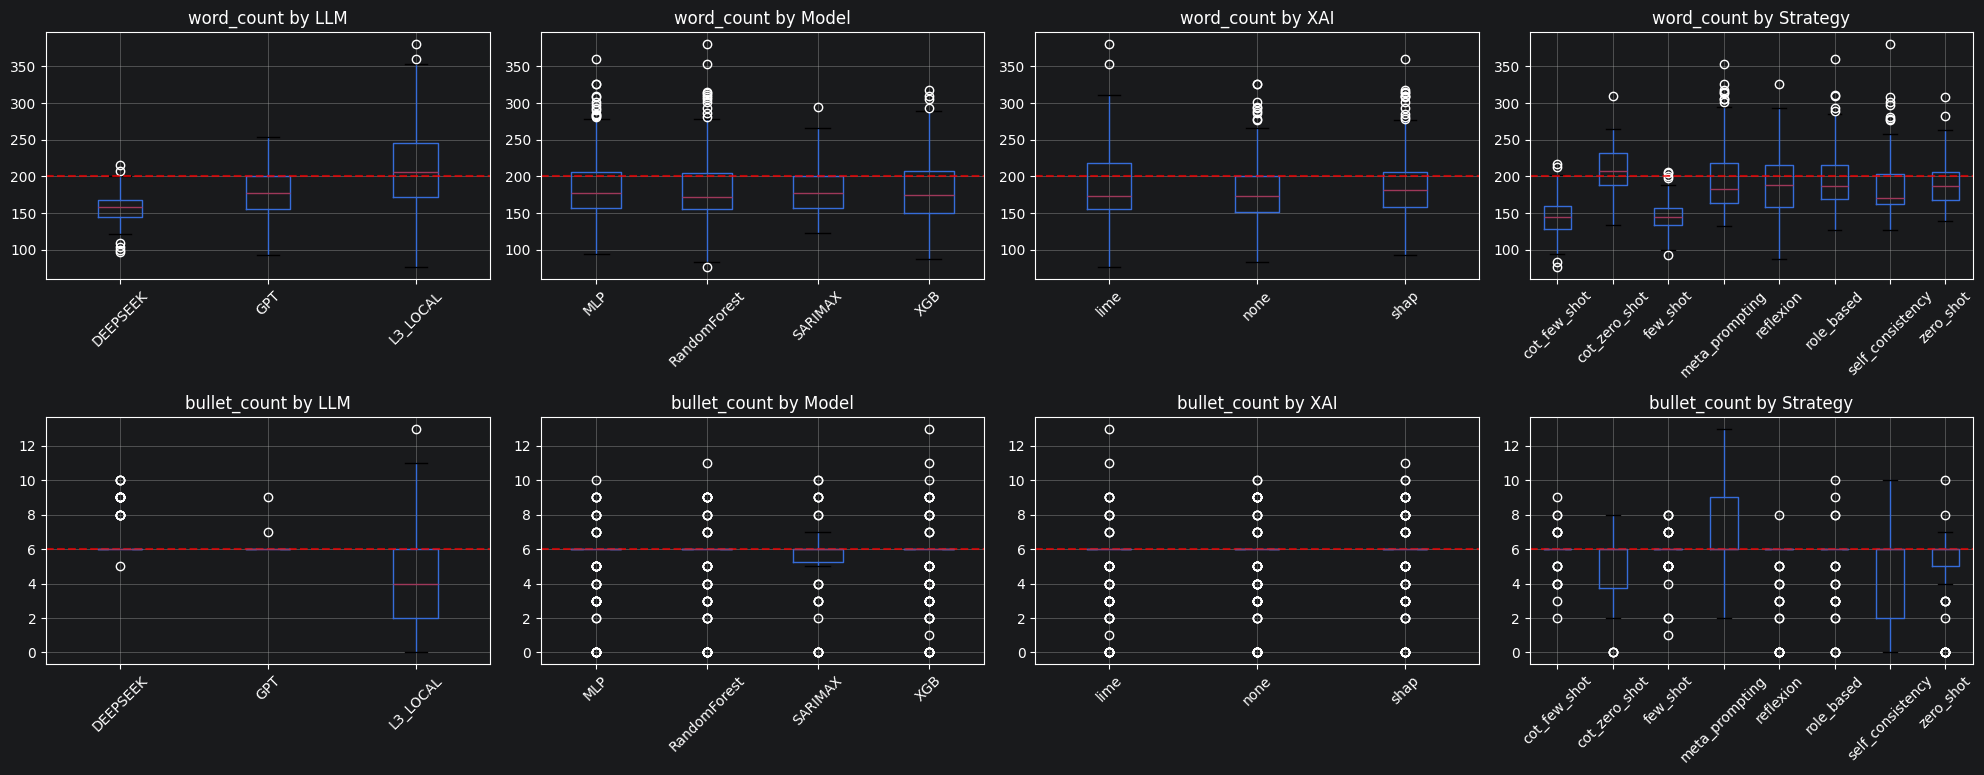

In [18]:
df['word_count'] = df['Explanation'].fillna('').apply(lambda x: len(x.split()))
def count_bullets(t):
    if pd.isna(t): return 0
    return sum(1 for l in t.strip().split('\n') if re.match(r'^\s*[-\u2022*]\s|^\s*\d+[.)]\s', l))
df['bullet_count'] = df['Explanation'].apply(count_bullets)

for label, col, th in [('Word Count (<=200)','word_count',200),('Bullet Points (<=6)','bullet_count',6)]:
    ok = (df[col] <= th).sum()
    print(f'=== {label} ===')
    print(f'Compliant: {ok}/660 ({ok/660*100:.1f}%), Mean={df[col].mean():.1f}, SD={df[col].std():.1f}, Min={df[col].min()}, Max={df[col].max()}')
    v = df[df[col] > th]
    if len(v) > 0:
        print(f'Violations ({len(v)}):')
        for fac in ['LLM','Model','XAI','Strategy']:
            print(f'  {fac}: {dict(v[fac].value_counts())}')
    print()

fig, axes = plt.subplots(2, 4, figsize=(20,8))
for i,(m,th) in enumerate([('word_count',200),('bullet_count',6)]):
    for j,fac in enumerate(['LLM','Model','XAI','Strategy']):
        ax = axes[i][j]; df.boxplot(column=m, by=fac, ax=ax, rot=45)
        ax.axhline(y=th, color='r', ls='--', alpha=0.7); ax.set_title(f'{m} by {fac}'); ax.set_xlabel('')
plt.suptitle(''); plt.tight_layout(); plt.show()

---
## Part B: Helper Function (Steps 1-5 + sections 8-9)

In [19]:
def compute_emms(model, data, focal, others):
    """Estimated Marginal Means via balanced prediction grid."""
    other_cols = others + ['Instance']
    grid = pd.DataFrame(list(product(*[data[c].unique() for c in other_cols])), columns=other_cols)
    emms = {}
    for lev in sorted(data[focal].unique()):
        g = grid.copy(); g[focal] = lev
        try: emms[lev] = model.predict(g).mean()
        except: emms[lev] = data[data[focal]==lev][model.model.endog_names].mean()
    return emms

def run_rq(data, focal, others, rq_name):
    """Full protocol: Steps 1-5 + FDR."""
    print(f'\n{"="*70}\n  {rq_name}: Effect of {focal} (N={len(data)})\n{"="*70}')
    all_fac = [focal] + others + ['Instance']
    results = {}
    
    for dim in DIMENSIONS:
        print(f'\n{chr(9472)*50}\n  {dim}\n{chr(9472)*50}')
        
        # Step 1: Descriptive
        desc = data.groupby(focal)[dim].agg(['mean','std','count'])
        desc['ceil_%'] = data.groupby(focal)[dim].apply(lambda x: (x==5.0).mean()*100)
        print(f'\nStep 1 -- Descriptive:'); print(desc.round(3).to_string())
        
        # Step 2: Interaction screening FIRST
        print(f'\nStep 2 -- Interaction screening:')
        sig_int = []
        for other in others:
            rem = [f for f in others if f != other]
            add = ' + '.join([f'C({f})' for f in rem + ['Instance']])
            try:
                mi = ols(f'{dim} ~ C({focal}) * C({other}) + {add}', data=data).fit()
                ai = sm.stats.anova_lm(mi, typ=2)
                ik = f'C({focal}):C({other})'
                if ik in ai.index:
                    Fi, pi = ai.loc[ik,'F'], ai.loc[ik,'PR(>F)']
                    s = '*' if pi < ALPHA else ''
                    print(f'  {focal} x {other}: F={Fi:.2f}, p={pi:.4f} {s}')
                    if pi < ALPHA: sig_int.append(other)
            except Exception as e: print(f'  {focal} x {other}: ERROR -- {e}')
        
        has_int = len(sig_int) > 0
        
        # Step 3: Simple effects (if interaction) or main effects
        if has_int:
            print(f'\nStep 3 -- Interaction(s): {sig_int}. Simple effects:')
            for ifac in sig_int:
                rem = [f for f in others if f != ifac]
                add = ' + '.join([f'C({f})' for f in rem + ['Instance']])
                for lev in sorted(data[ifac].unique()):
                    sub = data[data[ifac]==lev]
                    if len(sub) < 10: continue
                    try:
                        ms = ols(f'{dim} ~ C({focal}) + {add}', data=sub).fit()
                        a_s = sm.stats.anova_lm(ms, typ=2)
                        fk = f'C({focal})'
                        Fs, ps = a_s.loc[fk,'F'], a_s.loc[fk,'PR(>F)']
                        ssa, sse = a_s.loc[fk,'sum_sq'], a_s.loc['Residual','sum_sq']
                        print(f'    {ifac}={lev} (N={len(sub)}): F={Fs:.2f}, p={ps:.4f}, eta2p={ssa/(ssa+sse):.4f}')
                    except Exception as e: print(f'    {ifac}={lev}: ERROR -- {e}')
            print(f'\n  (Main effect for reference -- interpret conditionally):')
        else:
            print(f'\nStep 3 -- No interactions. Main effects:')
        
        # Additive model
        formula = dim + ' ~ ' + ' + '.join([f'C({f})' for f in all_fac])
        model = ols(formula, data=data).fit()
        anova = sm.stats.anova_lm(model, typ=2)
        fk = f'C({focal})'
        F_val, p_val = anova.loc[fk,'F'], anova.loc[fk,'PR(>F)']
        ss_a, ss_e = anova.loc[fk,'sum_sq'], anova.loc['Residual','sum_sq']
        ms_e = ss_e / anova.loc['Residual','df']
        eta = ss_a / (ss_a + ss_e)
        print(f'  ANOVA (Type II): F={F_val:.2f}, p={p_val:.4f}, eta2p={eta:.4f}')
        
        results[dim] = {'F':F_val,'p':p_val,'eta_sq_p':eta,'ms_e':ms_e,'model':model,
                        'has_interaction':has_int,'sig_interactions':sig_int,
                        'residuals':model.resid,'fitted':model.fittedvalues}
        
        # Step 4: Pairwise comparisons
        if p_val < ALPHA:
            print(f'\nStep 4 -- Pairwise (EMMs, d_RMSE, BH FDR):')
            emms = compute_emms(model, data, focal, others)
            levels = sorted(data[focal].unique())
            rmse = np.sqrt(ms_e)
            pairs = list(combinations(levels, 2))
            pr = []
            for l1, l2 in pairs:
                diff = emms[l1] - emms[l2]
                d = diff / rmse
                n1, n2 = len(data[data[focal]==l1]), len(data[data[focal]==l2])
                se = rmse * np.sqrt(1/n1 + 1/n2)
                t = diff / se
                df_r = anova.loc['Residual','df']
                p_pair = 2 * (1 - scipy_stats.t.cdf(abs(t), df_r))
                ci_lo, ci_hi = diff - 1.96*se, diff + 1.96*se
                pr.append({'pair':f'{l1} vs {l2}','diff':diff,'d_RMSE':d,'p_raw':p_pair,'CI_lo':ci_lo,'CI_hi':ci_hi})
            
            raw_ps = [r['p_raw'] for r in pr]
            if len(raw_ps) > 1:
                _, p_fdr, _, _ = multipletests(raw_ps, alpha=ALPHA, method='fdr_bh')
            else:
                p_fdr = raw_ps
            for r, pf in zip(pr, p_fdr):
                r['p_fdr'] = pf
                sig = '*' if pf < ALPHA else ''
                print(f'  {r["pair"]:>30s}: d={r["diff"]:+.3f} [{r["CI_lo"]:+.3f},{r["CI_hi"]:+.3f}], d_RMSE={r["d_RMSE"]:+.3f}, p_fdr={pf:.4f} {sig}')
            results[dim]['pairwise'] = pr
        else:
            print(f'\nStep 4 -- Not significant, no pairwise.')
    
    # FDR across 3 dimensions (section 9 omnibus family)
    print(f'\n{chr(9472)*50}\n  BH FDR across dimensions\n{chr(9472)*50}')
    omni = [results[d]['p'] for d in DIMENSIONS]
    _, pfo, _, _ = multipletests(omni, alpha=ALPHA, method='fdr_bh')
    for dim, pr, pa in zip(DIMENSIONS, omni, pfo):
        sig = '*' if pa < ALPHA else ''
        print(f'  {dim:<16s}: p_raw={pr:.4f}, p_fdr={pa:.4f} {sig}')
        results[dim]['p_fdr'] = pa
    
    # Step 5: Diagnostic plots
    fig, axes = plt.subplots(2, 3, figsize=(15,8))
    fig.suptitle(f'{rq_name} -- Diagnostics', fontsize=14)
    for j, dim in enumerate(DIMENSIONS):
        r, f_ = results[dim]['residuals'], results[dim]['fitted']
        axes[0][j].scatter(f_, r, alpha=0.3, s=10); axes[0][j].axhline(0, color='r', ls='--')
        axes[0][j].set_title(f'{dim} -- Resid vs Fitted'); axes[0][j].set_xlabel('Fitted'); axes[0][j].set_ylabel('Residuals')
        scipy_stats.probplot(r, dist='norm', plot=axes[1][j]); axes[1][j].set_title(f'{dim} -- Q-Q')
    plt.tight_layout(); plt.show()
    
    return results

---
## RQ-Q1: XAI Method (SARIMAX excluded, N=594)


  RQ-Q1 (XAI): Effect of XAI (N=594)

──────────────────────────────────────────────────
  Accuracy
──────────────────────────────────────────────────

Step 1 -- Descriptive:
       mean    std  count  ceil_%
XAI                              
lime  4.573  0.555    198   0.000
none  4.489  0.601    198   1.515
shap  4.533  0.555    198   0.000

Step 2 -- Interaction screening:
  XAI x LLM: F=2.74, p=0.0280 *
  XAI x Model: F=0.57, p=0.6809 
  XAI x Strategy: F=1.71, p=0.0504 

Step 3 -- Interaction(s): ['LLM']. Simple effects:
    LLM=DEEPSEEK (N=162): F=3.90, p=0.0222, eta2p=0.0495
    LLM=GPT (N=216): F=2.62, p=0.0750, eta2p=0.0253
    LLM=L3_LOCAL (N=216): F=2.21, p=0.1122, eta2p=0.0214

  (Main effect for reference -- interpret conditionally):
  ANOVA (Type II): F=1.59, p=0.2040, eta2p=0.0055

Step 4 -- Not significant, no pairwise.

──────────────────────────────────────────────────
  Lay_Relevancy
──────────────────────────────────────────────────

Step 1 -- Descriptive:
       m

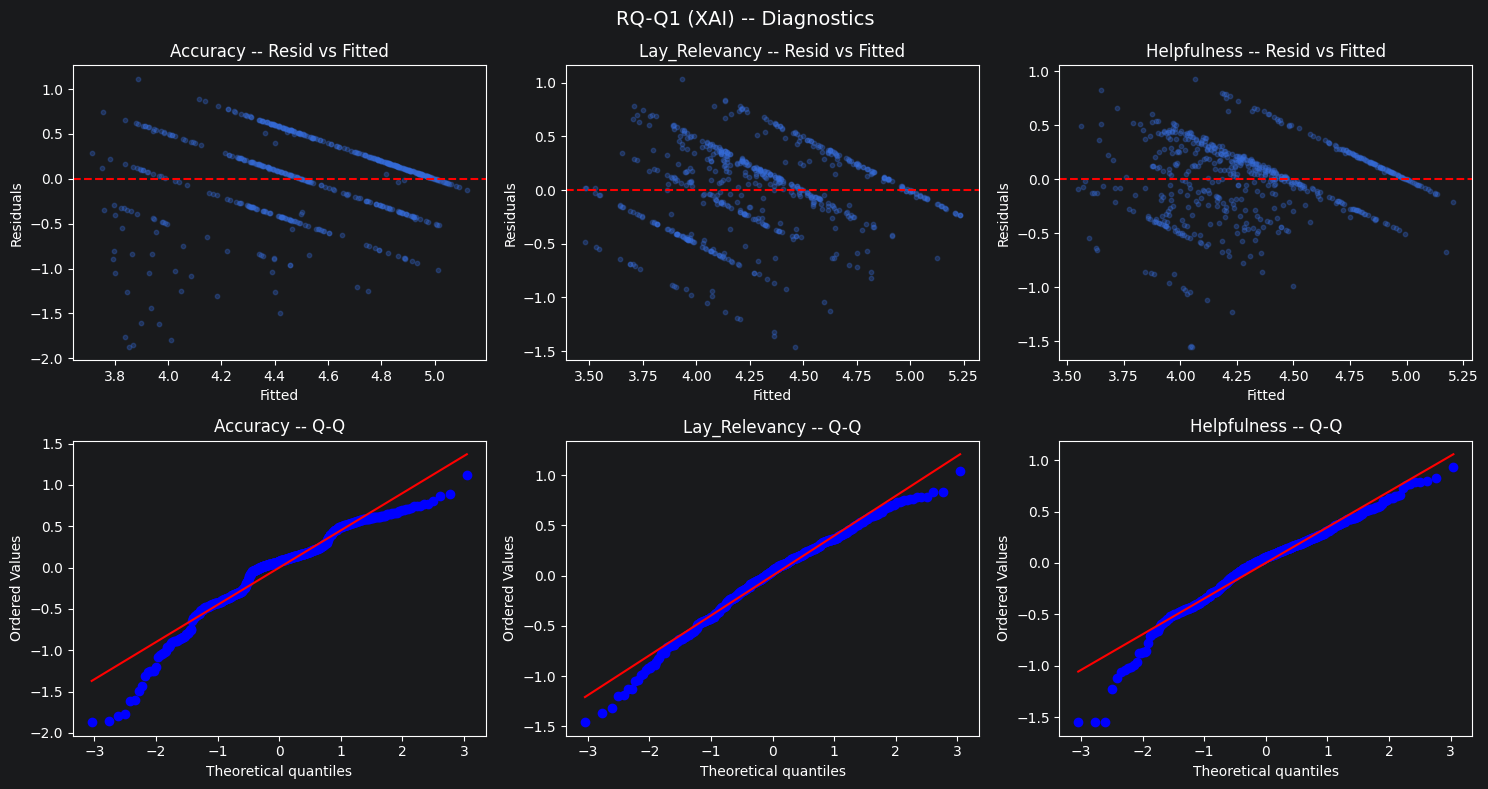

In [20]:
rq_q1 = run_rq(df_no_sarimax, 'XAI', ['LLM','Model','Strategy'], 'RQ-Q1 (XAI)')

## RQ-Q2: LLM Choice (Full, N=660)


  RQ-Q2 (LLM): Effect of LLM (N=660)

──────────────────────────────────────────────────
  Accuracy
──────────────────────────────────────────────────

Step 1 -- Descriptive:
           mean    std  count  ceil_%
LLM                                  
DEEPSEEK  4.711  0.341    180    0.00
GPT       4.727  0.401    240    0.00
L3_LOCAL  4.184  0.704    240    1.25

Step 2 -- Interaction screening:
  LLM x Model: F=1.33, p=0.2419 
  LLM x XAI: F=1.97, p=0.0971 
  LLM x Strategy: F=19.06, p=0.0000 *

Step 3 -- Interaction(s): ['Strategy']. Simple effects:
    Strategy=cot_few_shot (N=60): F=39.28, p=0.0000, eta2p=0.4351
    Strategy=cot_zero_shot (N=60): F=10.81, p=0.0018, eta2p=0.1750
    Strategy=few_shot (N=90): F=29.10, p=0.0000, eta2p=0.4212
    Strategy=meta_prompting (N=90): F=12.71, p=0.0000, eta2p=0.2412
    Strategy=reflexion (N=90): F=7.13, p=0.0014, eta2p=0.1513
    Strategy=role_based (N=90): F=11.22, p=0.0001, eta2p=0.2190
    Strategy=self_consistency (N=90): F=10.66, p=0.0

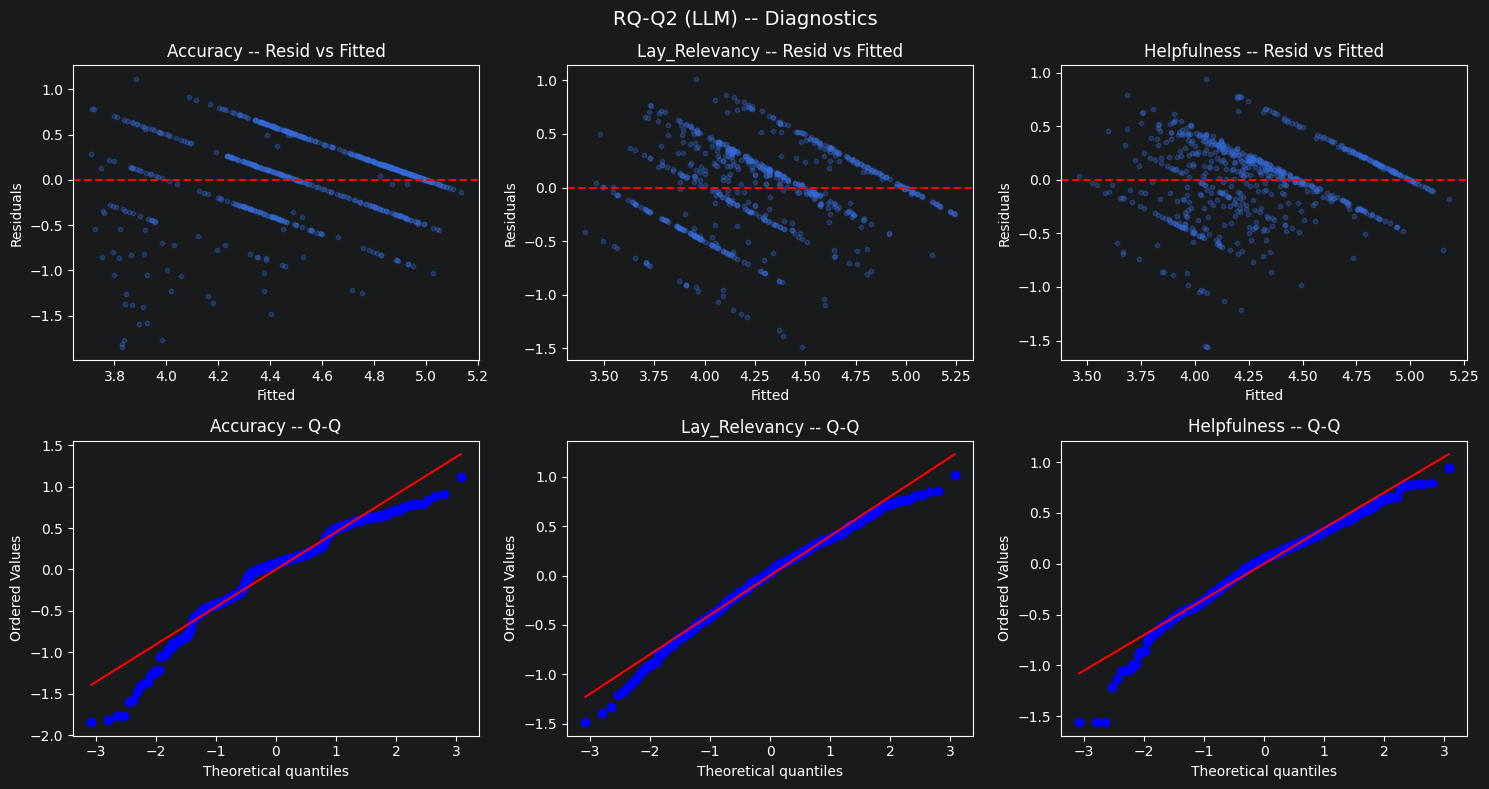

In [21]:
rq_q2 = run_rq(df_full, 'LLM', ['Model','XAI','Strategy'], 'RQ-Q2 (LLM)')

## RQ-Q3: ML Model (SARIMAX excluded, N=594)


  RQ-Q3 (ML model): Effect of Model (N=594)

──────────────────────────────────────────────────
  Accuracy
──────────────────────────────────────────────────

Step 1 -- Descriptive:
               mean    std  count  ceil_%
Model                                    
MLP           4.496  0.614    198   0.505
RandomForest  4.534  0.547    198   0.505
XGB           4.564  0.550    198   0.505

Step 2 -- Interaction screening:
  Model x LLM: F=0.81, p=0.5175 
  Model x XAI: F=0.57, p=0.6809 
  Model x Strategy: F=0.88, p=0.5843 

Step 3 -- No interactions. Main effects:
  ANOVA (Type II): F=1.04, p=0.3554, eta2p=0.0036

Step 4 -- Not significant, no pairwise.

──────────────────────────────────────────────────
  Lay_Relevancy
──────────────────────────────────────────────────

Step 1 -- Descriptive:
               mean    std  count  ceil_%
Model                                    
MLP           4.123  0.524    198     0.0
RandomForest  4.285  0.552    198     0.0
XGB           4.535  0.47

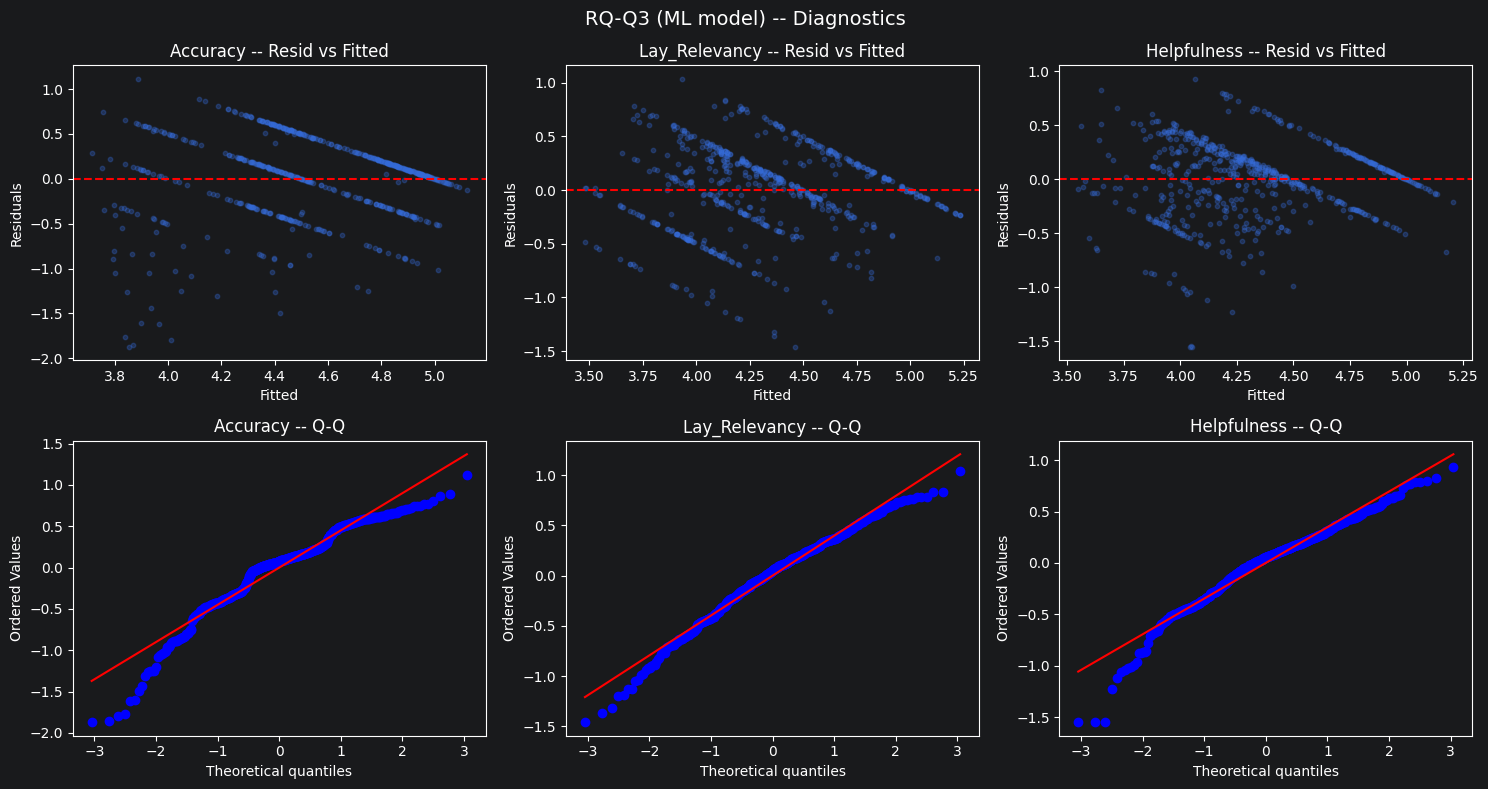

In [22]:
rq_q3 = run_rq(df_no_sarimax, 'Model', ['LLM','XAI','Strategy'], 'RQ-Q3 (ML model)')

## RQ-Q4: Interpretability (XAI=None, N=264)


  RQ-Q4 (Interpretability): Effect of Model (N=264)

──────────────────────────────────────────────────
  Accuracy
──────────────────────────────────────────────────

Step 1 -- Descriptive:
               mean    std  count  ceil_%
Model                                    
MLP           4.501  0.615     66   1.515
RandomForest  4.457  0.639     66   1.515
SARIMAX       4.465  0.659     66   0.000
XGB           4.509  0.556     66   1.515

Step 2 -- Interaction screening:
  Model x LLM: F=1.64, p=0.1364 
  Model x Strategy: F=1.21, p=0.2436 

Step 3 -- No interactions. Main effects:
  ANOVA (Type II): F=0.18, p=0.9085, eta2p=0.0022

Step 4 -- Not significant, no pairwise.

──────────────────────────────────────────────────
  Lay_Relevancy
──────────────────────────────────────────────────

Step 1 -- Descriptive:
               mean    std  count  ceil_%
Model                                    
MLP           4.072  0.452     66     0.0
RandomForest  4.263  0.494     66     0.0
SARIMAX 

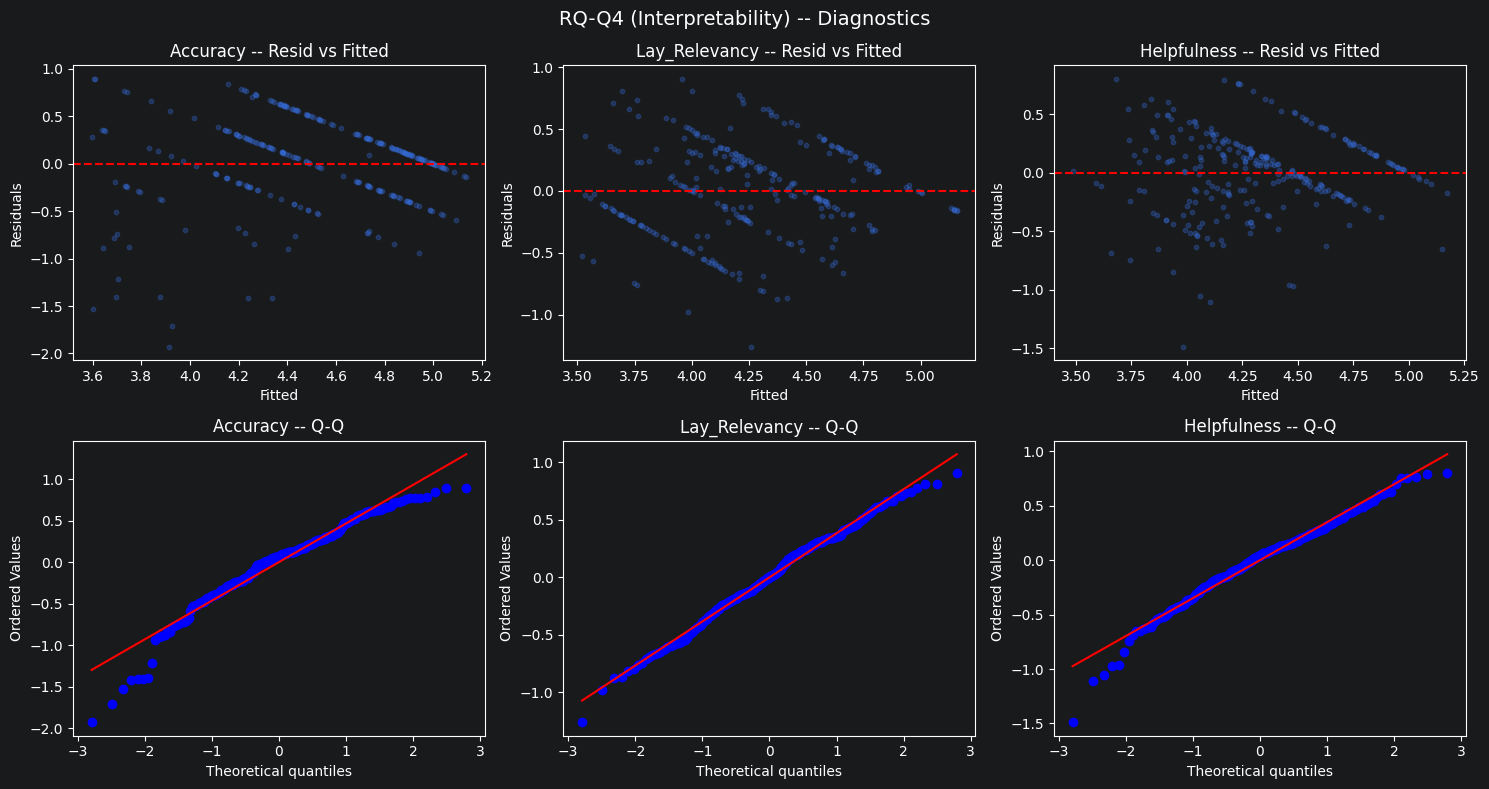

In [23]:
rq_q4 = run_rq(df_xai_none, 'Model', ['LLM','Strategy'], 'RQ-Q4 (Interpretability)')

## RQ-Q5: Strategy (Full, N=660)


  RQ-Q5 (Strategy): Effect of Strategy (N=660)

──────────────────────────────────────────────────
  Accuracy
──────────────────────────────────────────────────

Step 1 -- Descriptive:
                   mean    std  count  ceil_%
Strategy                                     
cot_few_shot      4.132  0.771     60   0.000
cot_zero_shot     4.714  0.433     60   0.000
few_shot          4.331  0.719     90   0.000
meta_prompting    4.218  0.581     90   0.000
reflexion         4.743  0.376     90   0.000
role_based        4.580  0.504     90   1.111
self_consistency  4.717  0.418     90   2.222
zero_shot         4.697  0.411     90   0.000

Step 2 -- Interaction screening:
  Strategy x LLM: F=19.06, p=0.0000 *
  Strategy x Model: F=0.87, p=0.6358 
  Strategy x XAI: F=1.65, p=0.0611 

Step 3 -- Interaction(s): ['LLM']. Simple effects:
    LLM=DEEPSEEK (N=180): F=5.83, p=0.0001, eta2p=0.1486
    LLM=GPT (N=240): F=9.76, p=0.0000, eta2p=0.2330
    LLM=L3_LOCAL (N=240): F=12.30, p=0.0000, et

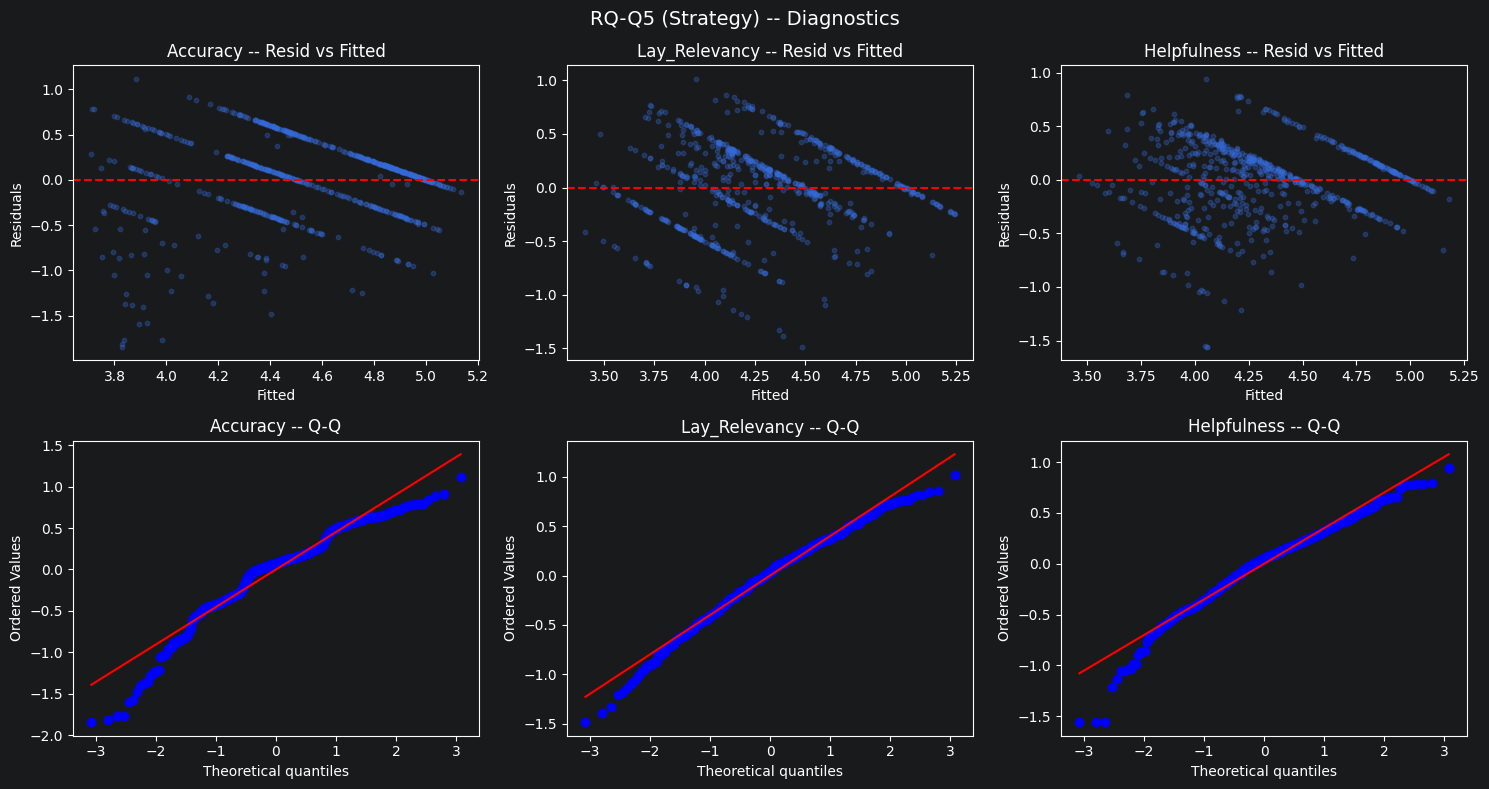

In [24]:
rq_q5 = run_rq(df_full, 'Strategy', ['LLM','Model','XAI'], 'RQ-Q5 (Strategy)')

---
## Robustness Checks (section 10)

### 10.1 Inter-Judge Agreement & Judge-Specific Models

In [25]:
print('=== Inter-Judge Agreement ===')
for dim in DIMENSIONS:
    g, d = f'{dim}_gpt', f'{dim}_ds'
    print(f'  {dim}: Pearson={df[g].corr(df[d]):.3f}, Spearman={df[g].corr(df[d], method="spearman"):.3f}, MAD={(df[g]-df[d]).abs().mean():.3f}')

rq_cfgs = [
    ('RQ-Q1','XAI',['LLM','Model','Strategy'],df_no_sarimax),
    ('RQ-Q2','LLM',['Model','XAI','Strategy'],df_full),
    ('RQ-Q3','Model',['LLM','XAI','Strategy'],df_no_sarimax),
    ('RQ-Q4','Model',['LLM','Strategy'],df_xai_none),
    ('RQ-Q5','Strategy',['LLM','Model','XAI'],df_full),
]
print(f'\n=== Judge-Specific Models ===')
print(f'{"RQ":<8}{"Dim":<16}{"Judge":<10}{"F":>8}{"p":>10}{"eta2p":>8}')
print('-'*60)
for rq,focal,others,data in rq_cfgs:
    for dim in DIMENSIONS:
        for suf,jn in [('_gpt','GPT-4o'),('_ds','DeepSeek')]:
            col = f'{dim}{suf}'
            fp = ' + '.join([f'C({f})' for f in [focal]+others+['Instance']])
            try:
                m = ols(f'{col} ~ {fp}', data=data).fit()
                a = sm.stats.anova_lm(m, typ=2); fk = f'C({focal})'
                F,p = a.loc[fk,'F'], a.loc[fk,'PR(>F)']
                ssa,sse = a.loc[fk,'sum_sq'], a.loc['Residual','sum_sq']
                sig = '*' if p < 0.05 else ''
                print(f'{rq:<8}{dim:<16}{jn:<10}{F:>8.2f}{p:>9.4f}{sig}{ssa/(ssa+sse):>8.4f}')
            except: print(f'{rq:<8}{dim:<16}{jn:<10} ERROR')

=== Inter-Judge Agreement ===
  Accuracy: Pearson=0.377, Spearman=0.424, MAD=0.740
  Lay_Relevancy: Pearson=0.374, Spearman=0.422, MAD=0.589
  Helpfulness: Pearson=0.570, Spearman=0.703, MAD=0.654

=== Judge-Specific Models ===
RQ      Dim             Judge            F         p   eta2p
------------------------------------------------------------
RQ-Q1   Accuracy        GPT-4o        1.93   0.1460  0.0066
RQ-Q1   Accuracy        DeepSeek      0.88   0.4142  0.0030
RQ-Q1   Lay_Relevancy   GPT-4o        0.13   0.8782  0.0004
RQ-Q1   Lay_Relevancy   DeepSeek      0.20   0.8183  0.0007
RQ-Q1   Helpfulness     GPT-4o        5.15   0.0061*  0.0175
RQ-Q1   Helpfulness     DeepSeek      0.95   0.3863  0.0033
RQ-Q2   Accuracy        GPT-4o       21.43   0.0000*  0.0625
RQ-Q2   Accuracy        DeepSeek     94.14   0.0000*  0.2265
RQ-Q2   Lay_Relevancy   GPT-4o       39.38   0.0000*  0.1091
RQ-Q2   Lay_Relevancy   DeepSeek    169.01   0.0000*  0.3446
RQ-Q2   Helpfulness     GPT-4o      116.40   

### 10.3 With vs Without Instance Blocking

In [26]:
print(f'{"RQ":<8}{"Dim":<16}{"Blocked p":>12}{"Unblocked p":>12}{"Changed?":>10}')
print('-'*62)
for rq,focal,others,data in rq_cfgs:
    for dim in DIMENSIONS:
        fb = ' + '.join([f'C({f})' for f in [focal]+others+['Instance']])
        fu = ' + '.join([f'C({f})' for f in [focal]+others])
        pb = sm.stats.anova_lm(ols(f'{dim} ~ {fb}', data=data).fit(), typ=2).loc[f'C({focal})','PR(>F)']
        pu = sm.stats.anova_lm(ols(f'{dim} ~ {fu}', data=data).fit(), typ=2).loc[f'C({focal})','PR(>F)']
        sb,su = '*' if pb<0.05 else ' ', '*' if pu<0.05 else ' '
        print(f'{rq:<8}{dim:<16}{pb:>10.4f}{sb}{pu:>10.4f}{su}{"YES" if sb!=su else "":>10}')

RQ      Dim                Blocked p Unblocked p  Changed?
--------------------------------------------------------------
RQ-Q1   Accuracy            0.2040     0.2085           
RQ-Q1   Lay_Relevancy       0.9972     0.9972           
RQ-Q1   Helpfulness         0.0453*    0.0460*          
RQ-Q2   Accuracy            0.0000*    0.0000*          
RQ-Q2   Lay_Relevancy       0.0000*    0.0000*          
RQ-Q2   Helpfulness         0.0000*    0.0000*          
RQ-Q3   Accuracy            0.3554     0.3604           
RQ-Q3   Lay_Relevancy       0.0000*    0.0000*          
RQ-Q3   Helpfulness         0.0000*    0.0000*          
RQ-Q4   Accuracy            0.9085     0.9087           
RQ-Q4   Lay_Relevancy       0.0000*    0.0000*          
RQ-Q4   Helpfulness         0.0000*    0.0000*          
RQ-Q5   Accuracy            0.0000*    0.0000*          
RQ-Q5   Lay_Relevancy       0.0000*    0.0000*          
RQ-Q5   Helpfulness         0.0000*    0.0000*          


### 10.4 HC3 Robust Standard Errors

In [27]:
print(f'{"RQ":<8}{"Dim":<16}{"OLS p":>10}{"HC3 p":>10}{"Changed?":>10}')
print('-'*56)
for rq,focal,others,data in rq_cfgs:
    for dim in DIMENSIONS:
        fp = ' + '.join([f'C({f})' for f in [focal]+others+['Instance']])
        m = ols(f'{dim} ~ {fp}', data=data).fit()
        mhc = m.get_robustcov_results(cov_type='HC3')
        p_ols = sm.stats.anova_lm(m, typ=2).loc[f'C({focal})','PR(>F)']
        focal_params = [p for p in m.params.index if p.startswith(f'C({focal})')]
        try:
            rm = np.zeros((len(focal_params), len(m.params)))
            for i,p in enumerate(focal_params): rm[i, list(m.params.index).index(p)] = 1
            p_hc = float(mhc.f_test(rm).pvalue)
        except: p_hc = np.nan
        so,sh = '*' if p_ols<0.05 else ' ', '*' if p_hc<0.05 else ' '
        print(f'{rq:<8}{dim:<16}{p_ols:>8.4f}{so}{p_hc:>8.4f}{sh}{"YES" if so!=sh else "":>10}')

RQ      Dim                  OLS p     HC3 p  Changed?
--------------------------------------------------------
RQ-Q1   Accuracy          0.2040   0.2356           
RQ-Q1   Lay_Relevancy     0.9972   0.9972           
RQ-Q1   Helpfulness       0.0453*  0.0484*          
RQ-Q2   Accuracy          0.0000*  0.0000*          
RQ-Q2   Lay_Relevancy     0.0000*  0.0000*          
RQ-Q2   Helpfulness       0.0000*  0.0000*          
RQ-Q3   Accuracy          0.3554   0.3877           
RQ-Q3   Lay_Relevancy     0.0000*  0.0000*          
RQ-Q3   Helpfulness       0.0000*  0.0000*          
RQ-Q4   Accuracy          0.9085   0.9117           
RQ-Q4   Lay_Relevancy     0.0000*  0.0000*          
RQ-Q4   Helpfulness       0.0000*  0.0000*          
RQ-Q5   Accuracy          0.0000*  0.0000*          
RQ-Q5   Lay_Relevancy     0.0000*  0.0000*          
RQ-Q5   Helpfulness       0.0000*  0.0000*          


### 10.5 Non-Parametric (Kruskal-Wallis)

In [28]:
print(f'{"RQ":<8}{"Dim":<16}{"KW H":>10}{"KW p":>10}{"ANOVA p":>10}{"Agree?":>8}')
print('-'*64)
for rq,focal,others,data in rq_cfgs:
    for dim in DIMENSIONS:
        groups = [g[dim].values for _,g in data.groupby(focal)]
        H, pkw = scipy_stats.kruskal(*groups)
        fp = ' + '.join([f'C({f})' for f in [focal]+others+['Instance']])
        pan = sm.stats.anova_lm(ols(f'{dim} ~ {fp}', data=data).fit(), typ=2).loc[f'C({focal})','PR(>F)']
        agree = 'yes' if (pkw<0.05)==(pan<0.05) else 'NO'
        print(f'{rq:<8}{dim:<16}{H:>10.2f}{pkw:>9.4f}{pan:>10.4f}{agree:>8}')

RQ      Dim                   KW H      KW p   ANOVA p  Agree?
----------------------------------------------------------------
RQ-Q1   Accuracy              0.59   0.7433    0.2040     yes
RQ-Q1   Lay_Relevancy         0.24   0.8858    0.9972     yes
RQ-Q1   Helpfulness           3.85   0.1460    0.0453      NO
RQ-Q2   Accuracy            106.18   0.0000    0.0000     yes
RQ-Q2   Lay_Relevancy       178.26   0.0000    0.0000     yes
RQ-Q2   Helpfulness         319.66   0.0000    0.0000     yes
RQ-Q3   Accuracy              0.69   0.7077    0.3554     yes
RQ-Q3   Lay_Relevancy        80.27   0.0000    0.0000     yes
RQ-Q3   Helpfulness          16.08   0.0003    0.0000     yes
RQ-Q4   Accuracy              0.29   0.9615    0.9085     yes
RQ-Q4   Lay_Relevancy        61.45   0.0000    0.0000     yes
RQ-Q4   Helpfulness          32.06   0.0000    0.0000     yes
RQ-Q5   Accuracy            131.73   0.0000    0.0000     yes
RQ-Q5   Lay_Relevancy        77.00   0.0000    0.0000     yes
RQ-Q

---
## Summary Table

In [29]:
all_r = {'RQ-Q1':rq_q1,'RQ-Q2':rq_q2,'RQ-Q3':rq_q3,'RQ-Q4':rq_q4,'RQ-Q5':rq_q5}
rows = []
for rq,res in all_r.items():
    for dim in DIMENSIONS:
        r = res[dim]
        rows.append({'RQ':rq,'Dimension':dim,'F':round(r['F'],2),'p_raw':round(r['p'],4),
            'p_fdr':round(r.get('p_fdr',r['p']),4),'eta_sq_p':round(r['eta_sq_p'],4),
            'Interaction':'Yes: '+', '.join(r['sig_interactions']) if r['has_interaction'] else 'No'})
summary = pd.DataFrame(rows)
summary['sig'] = summary['p_fdr'].apply(lambda p: '***' if p<.001 else '**' if p<.01 else '*' if p<.05 else '')
summary

,RQ,Dimension,F,p_raw,p_fdr,eta_sq_p,Interaction,sig
0,RQ-Q1,Accuracy,1.59,0.2040,0.3060,0.0055,Yes: LLM,
1,RQ-Q1,Lay_Relevancy,0.00,0.9972,0.9972,0.0000,Yes: LLM,
2,RQ-Q1,Helpfulness,3.11,0.0453,0.1359,0.0107,Yes: LLM,
3,RQ-Q2,Accuracy,96.87,0.0000,0.0000,0.2315,Yes: Strategy,***
4,RQ-Q2,Lay_Relevancy,134.35,0.0000,0.0000,0.2947,"Yes: XAI, Strategy",***
5,RQ-Q2,Helpfulness,237.96,0.0000,0.0000,0.4253,"Yes: XAI, Strategy",***
6,RQ-Q3,Accuracy,1.04,0.3554,0.3554,0.0036,No,
7,RQ-Q3,Lay_Relevancy,52.02,0.0000,0.0000,0.1525,No,***
8,RQ-Q3,Helpfulness,11.95,0.0000,0.0000,0.0397,No,***
9,RQ-Q4,Accuracy,0.18,0.9085,0.9085,0.0022,No,
